1. Import Library

In [1]:
#import những thư viện cần thiết
#nhóm xử lí dữ liệu
import pandas as pd
import numpy as np

#nhóm vẽ biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [2]:
#đọc dữ liệu từ file csv
df = pd.read_csv('../data/Crop_recommendation.csv')

#đọc 5 dòng đầu tiên của dữ liệu
print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


3. Dataset Overview

In [3]:
#số dòng và số cột của dữ liệu
print(df.shape)

#xem tên các cột của dữ liệu
print(df.columns)

#xem thông tin tổng quan về dữ liệu
print(df.info())

#xem thông tin thống kê về dữ liệu
print(df.describe())

(2200, 8)
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB
None
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5

4.  Data Quality Checking

In [4]:
#kiểm tra dữ liệu có bị thiếu hay không
missing_values = df.isnull().sum()

print("Số lượng giá trị bị thiếu trong mỗi cột:")
print(missing_values)
print("================================")

#kiểm tra dữ liệu có bị trùng hay không
duplicate_rows = df.duplicated().sum()

print("Số lượng dòng trùng lặp trong dữ liệu:", duplicate_rows)
print("================================")

#kiểm tra lại kiểu dữ liệu của các cột
print("Kiểu dữ liệu của các cột:")
print(df.dtypes)
print("================================")

#Kiểm tra giá trị bất thường trong các cột số liệu
print("Giá trị bất thường trong các cột số liệu:")
print(df.describe())
print("================================")

Số lượng giá trị bị thiếu trong mỗi cột:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Số lượng dòng trùng lặp trong dữ liệu: 0
Kiểu dữ liệu của các cột:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object
Giá trị bất thường trong các cột số liệu:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693  

Nhật xét
- Dataset không có giá trị thiếu.
- Không phát hiện dòng dữ liệu trùng lặp.
- Kiểu dữ liệu của các đặc trưng đều phù hợp, riêng cột label có kiểu object nên sẽ cần mã hóa ở bước tiền xử lý.
- Qua thống kê mô tả, chưa phát hiện giá trị bất thường rõ rệt trong các đặc trưng số

5. Exploratory Data Analysis

5.1.Phân bố biến mục tiêu

In [5]:
#đếm số lượng các loại cây trồng trong cột 'label'
label_counts = df['label'].value_counts()

print("Số lượng các loại cây trồng trong cột 'label':")
print(label_counts)

Số lượng các loại cây trồng trong cột 'label':
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


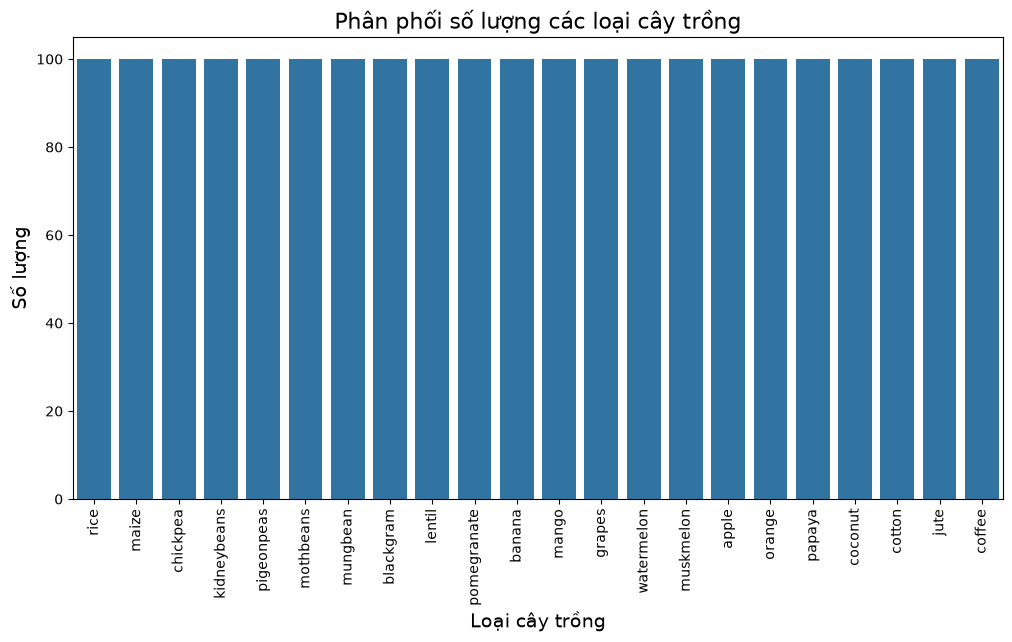

In [6]:
#vẽ biểu đồ phân phối số lượng các loại cây trồng
plt.figure(figsize=(12, 6))

sns.countplot(
    data = df,
    x = 'label',
    order = df['label'].value_counts().index
)

plt.title('Phân phối số lượng các loại cây trồng', fontsize=16)
plt.xlabel('Loại cây trồng', fontsize=14)
plt.ylabel('Số lượng', fontsize=14)

plt.xticks(rotation=90)
plt.show()

5.2.Histogram

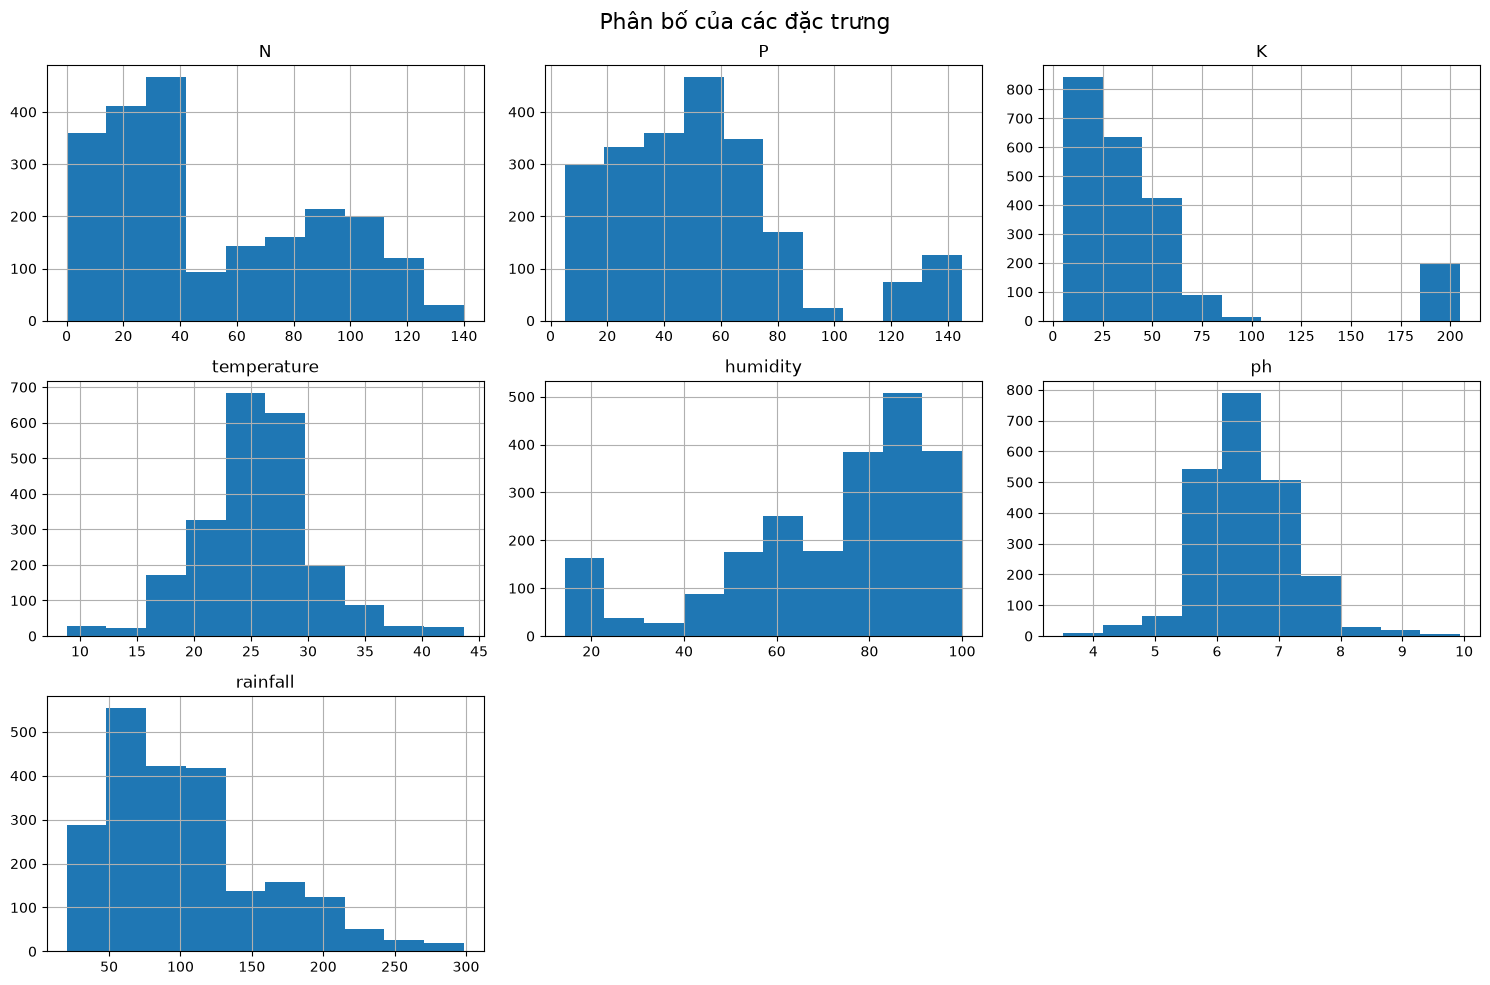

In [7]:
#quan sát sự phân bố của từ đặc trưng
df.hist(figsize=(15, 10))

plt.suptitle('Phân bố của các đặc trưng', fontsize=16)
plt.tight_layout()
plt.show()

5.3.Boxplot

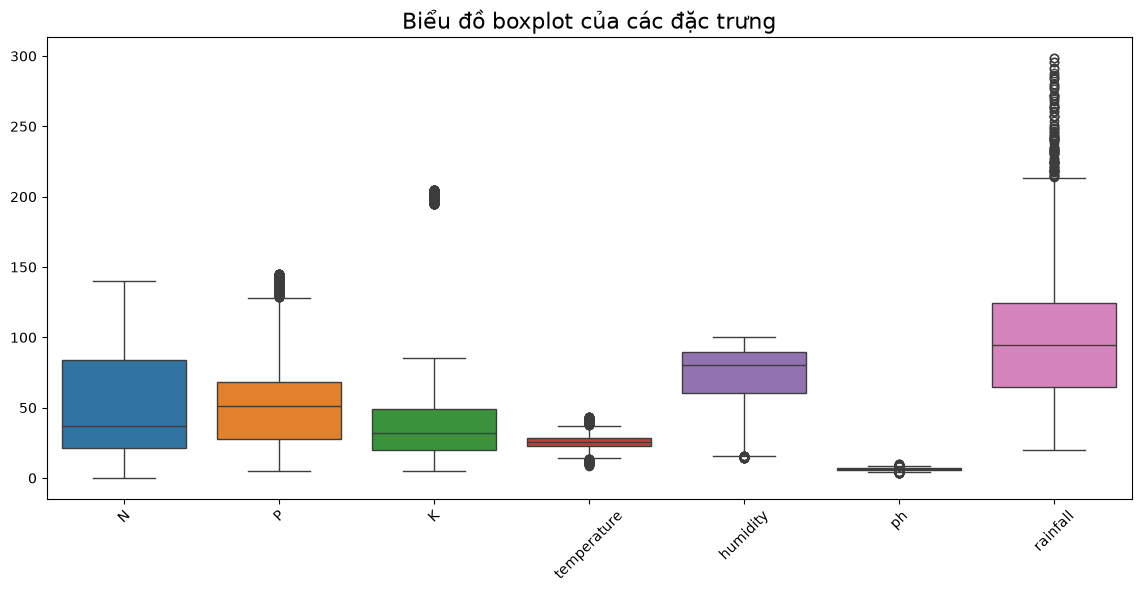

In [8]:
#kiểm tra có outlier trong các cột số liệu hay không bằng biểu đồ boxplot
plt.figure(figsize=(14,6))

sns.boxplot(data=df.drop(columns='label'))

plt.title("Biểu đồ boxplot của các đặc trưng", fontsize=16)

plt.xticks(rotation=45)

plt.show()

5.4.Correlation Heatmap

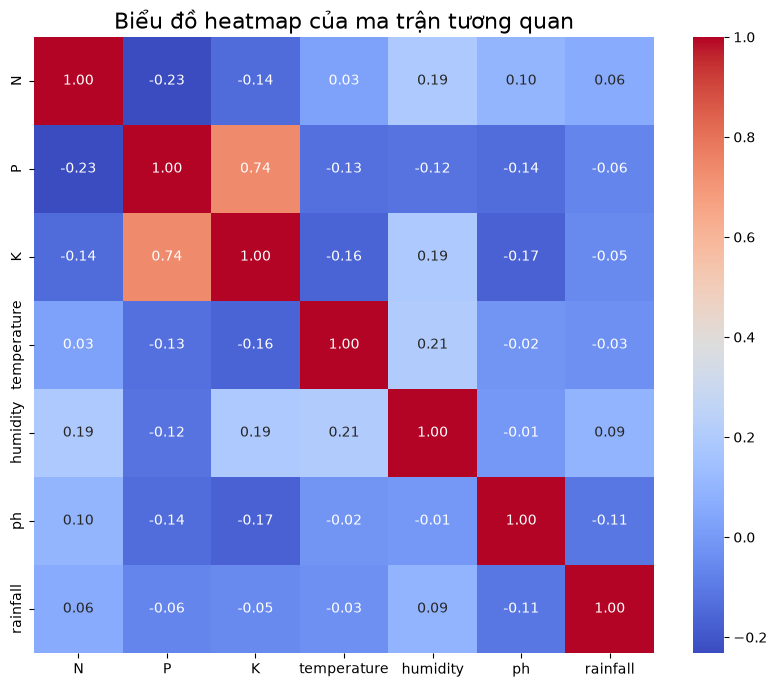

In [9]:
#xem các đặc trưng có liên quan với nhau hay không bằng biểu đồ heatmap
corr_matrix = df.drop(columns='label').corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt = '.2f'
)

plt.title("Biểu đồ heatmap của ma trận tương quan", fontsize=16)

plt.show()


Phần 2 - Tiền xử lý

In [10]:
#tách features và target
X = df.drop(columns='label')
y = df['label']

print("Kích thước của tập features (X):", X.shape)
print("Kích thước của tập target (y):", y.shape)

#kiểm tra dữ liệu
print("5 dòng đầu tiên của tập features (X):")
print(X.head())

print("5 dòng đầu tiên của tập target (y):")
print(y.head())

Kích thước của tập features (X): (2200, 7)
Kích thước của tập target (y): (2200,)
5 dòng đầu tiên của tập features (X):
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340
5 dòng đầu tiên của tập target (y):
0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: str


Nhận xét:
- Dataset được tách thành hai phần: tập đặc trưng (X) và biến mục tiêu (y).
- Tập đặc trưng gồm 7 thuộc tính đầu vào, trong khi biến mục tiêu là cột label.
- Việc tách dữ liệu ở giai đoạn này giúp chuẩn bị cho bước chia tập huấn luyện và kiểm tra, đồng thời tránh đưa biến mục tiêu vào quá trình huấn luyện như một đặc trưng.

In [11]:
#train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Kích thước của tập huấn luyện (X_train):", X_train.shape)
print("Kích thước của tập kiểm tra (X_test):", X_test.shape)
print("Kích thước của tập huấn luyện (y_train):", y_train.shape)
print("Kích thước của tập kiểm tra (y_test):", y_test.shape)


Kích thước của tập huấn luyện (X_train): (1760, 7)
Kích thước của tập kiểm tra (X_test): (440, 7)
Kích thước của tập huấn luyện (y_train): (1760,)
Kích thước của tập kiểm tra (y_test): (440,)


In [12]:
#label encoding - để chuyển đổi các nhãn cây trồng từ dạng chuỗi sang dạng số 
#để mô hình học máy có thể xử lý được.
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [13]:
#feature scaling - chuẩn hóa dữ liệu để các đặc trưng có cùng thang đo
#giúp mô hình học máy hoạt động hiệu quả hơn.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("====5 DÒNG ĐẦU TIÊN CỦA TẬP HUẤN LUYỆN ĐÃ CHUẨN HÓA====")
print(X_train_scaled[:5])  # in ra 5 dòng đầu tiên của tập huấn luyện đã chuẩn hóa

====5 DÒNG ĐẦU TIÊN CỦA TẬP HUẤN LUYỆN ĐÃ CHUẨN HÓA====
[[-1.37162846 -1.07290957 -0.67351002  0.81948109  0.92439516  0.93754456
   0.1994396 ]
 [-1.12741063  2.08451298  3.01526081  0.78325085  0.42661263 -1.15384595
  -0.64367687]
 [-1.07314     0.53616154 -0.47624954 -0.87996823 -2.18629069 -1.10745175
   0.69400094]
 [-0.34048652 -0.46571293 -0.59460583  0.1380426  -0.45923688 -0.22948193
  -1.23174354]
 [-0.8831928  -1.25506856 -0.7918663  -2.56323192  0.91584225 -0.34195907
   0.28994097]]


In [14]:
#kiểm tra kết quả tiền xử lý dữ liệu
#kiểm tra kích thước
print("X_train: ", X_train_scaled.shape)
print("X_test: ", X_test_scaled.shape)

print("y_train: ", y_train_encoded.shape)
print("y_test: ", y_test_encoded.shape)

#kiểm tra giá trị trung bình và độ lệch chuẩn của các đặc trưng sau khi chuẩn hóa
print("Mean: ", X_train_scaled.mean(axis=0))
print("Standard Deviation: ", X_train_scaled.std(axis=0))

X_train:  (1760, 7)
X_test:  (440, 7)
y_train:  (1760,)
y_test:  (440,)
Mean:  [ 2.82602224e-17  8.07434927e-17  5.55111512e-17 -2.82602224e-16
 -1.46347581e-16 -4.52163559e-16  2.22044605e-16]
Standard Deviation:  [1. 1. 1. 1. 1. 1. 1.]


============Huấn luyện mô hình==========

In [15]:
#import các mô hình học máy
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

#import metric
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

========HÀM DÙNG ĐỂ HUẤN LUYỆN VÀ ĐÁNH GIÁ CÁC MÔ HÌNH==========

In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Huấn luyện và đánh giá mô hình Machine Learning
    """

    # Huấn luyện
    model.fit(X_train, y_train)

    # Dự đoán
    y_pred = model.predict(X_test)

    # Đánh giá
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # In kết quả
    print("=" * 50)
    print(f"{model_name}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    # Trả kết quả để dùng sau
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Prediction": y_pred
    }

========KNN=======

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_result = evaluate_model(
    model=knn,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train_encoded,
    y_test=y_test_encoded,
    model_name="K-Nearest Neighbors"
)

K-Nearest Neighbors
Accuracy : 0.9795
Precision: 0.9804
Recall   : 0.9795
F1-score : 0.9793

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.91      1.00      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1

======SVM=====

In [18]:
svm = SVC(
    kernel="rbf",
    random_state=42
)

svm_result = evaluate_model(
    model=svm,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train_encoded,
    y_test=y_test_encoded,
    model_name="Support Vector Machine"
)

Support Vector Machine
Accuracy : 0.9841
Precision: 0.9856
Recall   : 0.9841
F1-score : 0.9840

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.90      0.95        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon     

=====RANDOM FOREST======

In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_result = evaluate_model(
    model=rf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train_encoded,
    y_test=y_test_encoded,
    model_name="Random Forest"
)

Random Forest
Accuracy : 0.9955
Precision: 0.9957
Recall   : 0.9955
F1-score : 0.9955

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00   

=====XGBOOST=====

In [20]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_result = evaluate_model(
    model=xgb,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train_encoded,
    y_test=y_test_encoded,
    model_name="XGBoost"
)

XGBoost
Accuracy : 0.9909
Precision: 0.9915
Recall   : 0.9909
F1-score : 0.9908

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.95      1.00      0.98        20
   muskmelon       1.00      1.0

====BẢNG SO SÁNH RÚT RA====

In [21]:
results = pd.DataFrame([
    knn_result,
    svm_result,
    rf_result,
    xgb_result
])

# Không cần cột Prediction trong bảng so sánh
results = results.drop(columns=["Prediction"])

# Sắp xếp theo Accuracy giảm dần
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.995455,0.995671,0.995455,0.995452
1,XGBoost,0.990909,0.991539,0.990909,0.990834
2,Support Vector Machine,0.984091,0.985610,0.984091,0.984038
3,K-Nearest Neighbors,0.979545,0.980356,0.979545,0.979283


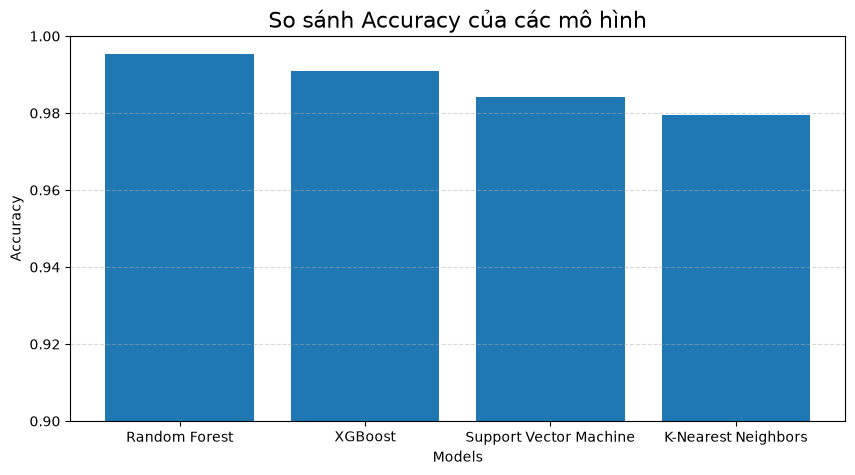

In [36]:
#Biểu đồ so sánh acurracy
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("So sánh Accuracy của các mô hình", fontsize=16)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.9,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [23]:
#chọn mô hình tốt nhất dựa trên accuracy
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)

if best_model_name == "K-Nearest Neighbors":
    best_model = knn

elif best_model_name == "Support Vector Machine":
    best_model = svm

elif best_model_name == "Random Forest":
    best_model = rf

else:
    best_model = xgb

Best Model: Random Forest


In [24]:
from sklearn.model_selection import GridSearchCV

# Bộ tham số cần thử
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True]
}

# Khởi tạo Random Forest
rf_base = RandomForestClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Huấn luyện
grid_search.fit(
    X_train,
    y_train_encoded
)

print("="*60)
print("Best Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy")
print(grid_search.best_score_)

# Lấy mô hình tốt nhất từ Grid Search
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters
{'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross Validation Accuracy
0.9960227272727271


In [25]:
rf_tuned_result = evaluate_model(
    model=best_rf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train_encoded,
    y_test=y_test_encoded,
    model_name="Random Forest (Tuned)"
)

Random Forest (Tuned)
Accuracy : 0.9955
Precision: 0.9957
Recall   : 0.9955
F1-score : 0.9955

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon      

In [26]:
#so sánh mô hình Random Forest trước và sau khi tinh chỉnh
comparison = pd.DataFrame([
    {
        "Model": rf_result["Model"],
        "Accuracy": rf_result["Accuracy"],
        "Precision": rf_result["Precision"],
        "Recall": rf_result["Recall"],
        "F1-score": rf_result["F1-score"]
    },
    {
        "Model": rf_tuned_result["Model"],
        "Accuracy": rf_tuned_result["Accuracy"],
        "Precision": rf_tuned_result["Precision"],
        "Recall": rf_tuned_result["Recall"],
        "F1-score": rf_tuned_result["F1-score"]
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.995455,0.995671,0.995455,0.995452
1,Random Forest (Tuned),0.995455,0.995671,0.995455,0.995452


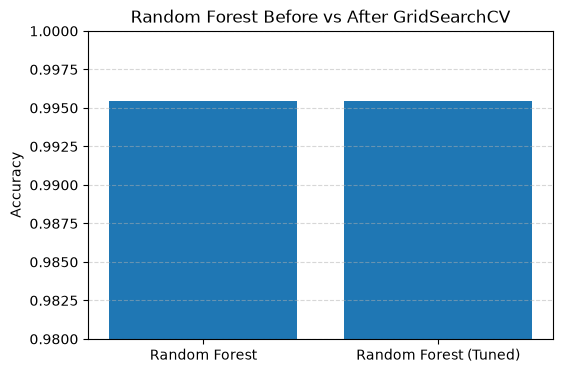

In [27]:
#biểu đồ so sánh accuracy của mô hình Random Forest trước và sau khi tinh chỉnh
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Random Forest Before vs After GridSearchCV")

plt.ylabel("Accuracy")

plt.ylim(0.98,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [28]:
#chọn mô hình tốt nhất dựa trên accuracy
if rf_tuned_result["Accuracy"] >= rf_result["Accuracy"]:
    best_model = best_rf
    final_result = rf_tuned_result
    print("Using Tuned Random Forest")
else:
    best_model = rf
    final_result = rf_result
    print("Using Original Random Forest")

Using Tuned Random Forest


In [29]:
#in ra kết quả cuối cùng
print("="*60)
print("FINAL MODEL")
print("="*60)

print("Model      :", final_result["Model"])
print(f"Accuracy   : {final_result['Accuracy']:.4f}")
print(f"Precision  : {final_result['Precision']:.4f}")
print(f"Recall     : {final_result['Recall']:.4f}")
print(f"F1-score   : {final_result['F1-score']:.4f}")

FINAL MODEL
Model      : Random Forest (Tuned)
Accuracy   : 0.9955
Precision  : 0.9957
Recall     : 0.9955
F1-score   : 0.9955


====Đánh giá mô hình & Lưu model====
- Confusion Matrix
- Feature Importance
- Lưu Model
- Lưu LabelEncoder & StandardScaler
- Kết luận

<Figure size 1200x1200 with 0 Axes>

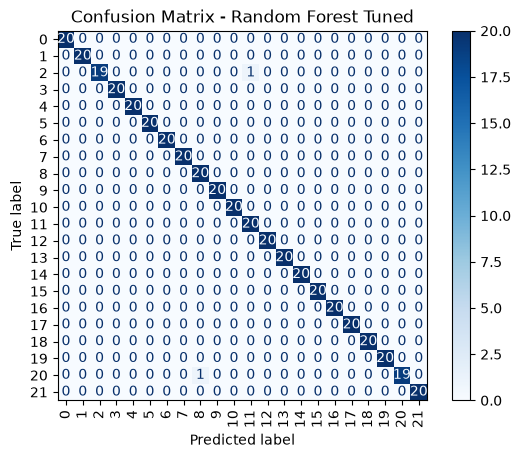

In [30]:
#confusion matrix - ma trận nhầm lẫn để đánh giá hiệu suất của mô hình phân loại
from sklearn.metrics import ConfusionMatrixDisplay

#tạo confusion matrix
y_pred = best_model.predict(X_test)

plt.figure(figsize=(12,12))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Confusion Matrix - Random Forest Tuned")

plt.show()

       Feature  Importance
6     rainfall    0.223133
4     humidity    0.216879
2            K    0.183446
1            P    0.145579
0            N    0.101962
3  temperature    0.075522
5           ph    0.053479


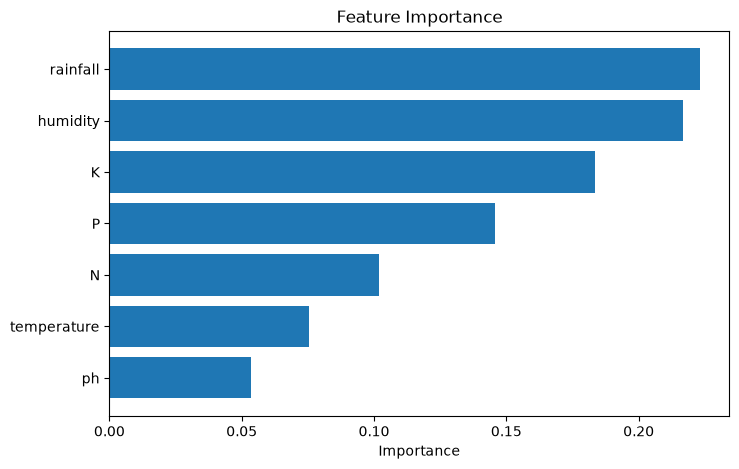

In [31]:
#feature importance - đánh giá tầm quan trọng của các đặc trưng trong mô hình Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

#vẽ biểu đồ feature importance
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [32]:
#cho mô hình thử dự đoán một mẫu mới
sample = pd.DataFrame({
    "N":[90],
    "P":[42],
    "K":[43],
    "temperature":[20.8],
    "humidity":[82],
    "ph":[6.5],
    "rainfall":[202]
})

sample = sample[X.columns]
prediction = best_model.predict(sample)
crop = label_encoder.inverse_transform(prediction)

print("Predicted Crop:", crop[0])

Predicted Crop: rice


In [33]:
#lưu model
import os
import joblib

# Tạo thư mục models nếu chưa tồn tại
os.makedirs("../models", exist_ok=True)

# Lưu mô hình Random Forest Tuned
joblib.dump(
    best_model,
    "../models/crop_model.pkl"
)

print("Random Forest Tuned đã được lưu vào thư mục models")

Random Forest Tuned đã được lưu vào thư mục models


In [34]:
# Lưu Label Encoder
joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

# Lưu StandardScaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Label Encoder và StandardScaler đã được lưu.")


Label Encoder và StandardScaler đã được lưu.


In [35]:
#load để kiểm tra
# Load model
loaded_model = joblib.load("../models/crop_model.pkl")

# Load Label Encoder
loaded_encoder = joblib.load("../models/label_encoder.pkl")

# Load Scaler
loaded_scaler = joblib.load("../models/scaler.pkl")

print("Tải các file thành công.")

Tải các file thành công.
